# Data Exploration

This is the notebook to explore the data and create database for the project.
</br>**NOTE: Some cells are inactive as 'raw', change to 'Python' if needed**

## Install & Import required libraries

In [10]:
# Inactive
%pip install pandas duckdb geopandas matplotlib requests fiona openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import duckdb
import openpyxl
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import os
import glob
import requests # for data set C API calls
from datetime import datetime  # for data validation step only
from pyproj import Proj

---

# CO2 Source (Emitter)

## Data Set A - EEA
Data set A was querried from MS Access for CO2 emission only. The data were downloaded for Version v_15_2025_12_15 (December 2025)
<br> Source: https://sdi.eea.europa.eu/catalogue/srv/eng/catalog.search#/metadata/3461f4ab-a3ee-4af2-bc11-95e651a8d0ba

### Create Database for Data set A (EEA)
Import excel file and store in DuckDB database

In [12]:
# import raw data (excel file)
EEA_CO2 = pd.read_excel('raw/EEA_CO2.xlsx')

# Check imported data
EEA_CO2

,pollutantCode,Facility_INSPIRE_ID,parentCompanyName,nameOfFeature,countryCode,NUTSRegionSourceCode,NUTSRegionSourceName,city,pointGeometryLat,pointGeometryLon,mainActivityCode,mainActivityName,reportingYear,totalPollutantQuantityKg,methodCode,methodName
0,CO2,AT.CAED/9008390306826.FACILITY,Mondi Neusiedler GmbH & Co KG,Mondi Neusiedler GmbH & Co KG,AT,AT121,Mostviertel-Eisenwurzen,Kematen,48.022778,14.753333,6(a),Industrial plants for the production of pulp f...,2012,102000000.0,C,Calculated: calculation method used
1,CO2,AT.CAED/9008390306826.FACILITY,Mondi Neusiedler GmbH & Co KG,Mondi Neusiedler GmbH & Co KG,AT,AT121,Mostviertel-Eisenwurzen,Kematen,48.022778,14.753333,6(a),Industrial plants for the production of pulp f...,2011,102000000.0,C,Calculated: calculation method used
2,CO2,AT.CAED/9008390306826.FACILITY,Mondi Neusiedler GmbH & Co KG,Mondi Neusiedler GmbH & Co KG,AT,AT121,Mostviertel-Eisenwurzen,Kematen,48.022778,14.753333,6(a),Industrial plants for the production of pulp f...,2010,106000000.0,C,Calculated: calculation method used
3,CO2,AT.CAED/9008390317211.FACILITY,Mondi Neusiedler GmbH & Co KG,Mondi Neusiedler GmbH & Co KG,AT,AT121,Mostviertel-Eisenwurzen,Hausmening,48.070000,14.820000,6(b),Industrial plants for the production of paper ...,2012,103000000.0,C,Calculated: calculation method used
4,CO2,AT.CAED/9008390317211.FACILITY,Mondi Neusiedler GmbH & Co KG,Mondi Neusiedler GmbH & Co KG,AT,AT121,Mostviertel-Eisenwurzen,Hausmening,48.070000,14.820000,6(b),Industrial plants for the production of paper ...,2011,101000000.0,C,Calculated: calculation method used
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37648,CO2,UK.SEPA/200002620.Facility,Total Exploration & Production UK Limited,Shetland Gas Plant,GB,UKM66,Shetland Islands,Shetland,60.468390,-1.259860,1(c),Thermal power stations and other combustion in...,2019,208000000.0,C,Calculated: calculation method used
37649,CO2,UK.SEPA/200002620.Facility,Total Exploration & Production UK Limited,Shetland Gas Plant,GB,UKM66,Shetland Islands,Shetland,60.468390,-1.259860,1(c),Thermal power stations and other combustion in...,2018,212000000.0,C,Calculated: calculation method used
37650,CO2,UK.SEPA/200002620.Facility,Total Exploration & Production UK Limited,Shetland Gas Plant,GB,UKM66,Shetland Islands,Shetland,60.468390,-1.259860,1(c),Thermal power stations and other combustion in...,2017,239000000.0,C,Calculated: calculation method used
37651,CO2,UK.SEPA/200002620.Facility,Total Exploration & Production UK Limited,Shetland Gas Plant,GB,UKM66,Shetland Islands,Shetland,60.468390,-1.259860,1(c),Thermal power stations and other combustion in...,2016,235000000.0,C,Calculated: calculation method used


### Querry database
Querry data from database.duckdb, and display selected sector, emissions >= 100 ktCO2, within study area

Selected sectors: Refinery, Steel, Cement, Waste-To-Energy, Power Generation, Coke/Coal Production, Petrochemicals
</br> See the code list of mainActivityCode in https://eur-lex.europa.eu/eli/reg/2006/166/oj/eng#ntr1-L_2006033EN.01000801-E0001



In [13]:
# Test connection and query
con = duckdb.connect('database.duckdb')

#Query to filter relevant sectors with emissions >= 100,000 kgCO2 and get most recent year per facility
query = """
WITH filtered_eea AS (
    SELECT * FROM EEA_CO2 
    WHERE (mainActivityCode LIKE '1(a)%'
       OR mainActivityCode LIKE '1(b)%' 
       OR mainActivityCode LIKE '1(c)%'
       OR mainActivityCode LIKE '1(d)%'
       OR mainActivityCode LIKE '1(e)%'
       OR mainActivityCode LIKE '2(a)%'
       OR mainActivityCode LIKE '2(c)%'
       OR mainActivityCode LIKE '2(d)'
       OR mainActivityCode LIKE '3(c)%'
       OR mainActivityCode LIKE '4(a)%'
       OR mainActivityCode LIKE '5(b)%')
       AND totalPollutantQuantityKg >= 100000000
       AND reportingYear >= 2023
),
ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY Facility_INSPIRE_ID
               ORDER BY reportingYear DESC
           ) AS rn
    FROM filtered_eea
)
SELECT * FROM ranked
WHERE rn = 1
"""

df_eea = con.execute(query).fetchdf()

# Print distinct main activity names after filtering
pd.set_option('display.max_colwidth', None)
print(con.execute("SELECT DISTINCT mainActivityCode FROM df_eea ORDER BY mainActivityCode").fetchdf())

con.close()

   mainActivityCode
0              1(a)
1              1(b)
2              1(c)
3              1(d)
4              1(e)
5              2(a)
6              2(c)
7           2(c)(i)
8              2(d)
9              3(c)
10          3(c)(i)
11         3(c)(ii)
12        3(c)(iii)
13             4(a)
14          4(a)(i)
15         4(a)(ii)
16        4(a)(iii)
17         4(a)(iv)
18         4(a)(vi)
19       4(a)(viii)
20             5(b)


In [14]:
df_eea

,pollutantCode,Facility_INSPIRE_ID,parentCompanyName,nameOfFeature,countryCode,NUTSRegionSourceCode,NUTSRegionSourceName,city,pointGeometryLat,pointGeometryLon,mainActivityCode,mainActivityName,reportingYear,totalPollutantQuantityKg,methodCode,methodName,rn
0,CO2,AT.CAED/9008390972489.FACILITY,Wiener Stadtwerke GmbH,WIEN ENERGIE GmbH,AT,AT130,Wien,"Wien,Simmering",48.182000,16.432000,1(c),Thermal power stations and other combustion installations,2024,925000000.0,C,Calculated: calculation method used,1
1,CO2,AT.CAED/9008390973899.FACILITY,Energie AG Oberösterreich Umwelt GmbH,Energie AG Oberösterreich Umwelt Service GmbH,AT,AT312,Linz-Wels,Wels,48.169833,14.076083,5(b),Installations for the incineration of non-hazardous waste in the scope of Directive 2000/76/EC of the European Parliament and of the Council of 4 December 2000 on the incineration of waste,2024,323000000.0,M,Measured: analytical method used,1
2,CO2,AT.CAED/9008391215691.FACILITY,FCC Austria Abfall Sevice AG,FCC Zistersdorf Abfall Service GmbH,AT,AT125,Weinviertel,Zistersdorf,48.548083,16.783472,5(b),Installations for the incineration of non-hazardous waste in the scope of Directive 2000/76/EC of the European Parliament and of the Council of 4 December 2000 on the incineration of waste,2024,156000000.0,M,Measured: analytical method used,1
3,CO2,BG.CAED/009000012.FACILITY,“ЕВН БЪЛГАРИЯ ТОПЛОФИКАЦИЯ” ЕАД,Plovdiv North power station,BG,BG421,Пловдив,Пловдив,42.183806,24.740972,1(c),Thermal power stations and other combustion installations,2023,134964000.0,C,Calculated: calculation method used,1
4,CO2,BG.CAED/012000011.FACILITY,"""ТОПЛОФИКАЦИЯ СОФИЯ"" ЕАД",Sofia Zemliane power station,BG,BG411,София (столица),София,42.686820,23.284390,1(c),Thermal power stations and other combustion installations,2023,157467000.0,C,Calculated: calculation method used,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1247,CO2,https://registry.gdi-de.org/id/de.sl.inspire.pf/0100999-G,Steag GmbH,Kraftwerk Bexbach,DE,DEC05,Saarpfalz-Kreis,Bexbach,49.364900,7.235490,1(c),Thermal power stations and other combustion installations,2024,296000000.0,C,Calculated: calculation method used,1
1248,CO2,https://registry.gdi-de.org/id/de.sl.inspire.pf/0105352-G,Energie SaarLorLux AG,Energie SaarLorLux AG Heizkraftwerk Römerbrücke,DE,DEC01,Regionalverband Saarbrücken,Saarbrücken,49.223700,7.014810,1(c),Thermal power stations and other combustion installations,2024,103000000.0,C,Calculated: calculation method used,1
1249,CO2,https://registry.gdi-de.org/id/de.sn.sax4inspire.pf/70015917,DREWAG Stadtwerke Dresden GmbH,DREWAG HKW Dresden-Reick,DE,DED21,"Dresden, Kreisfreie Stadt",Dresden,51.024480,13.783230,1(c),Thermal power stations and other combustion installations,2024,174000000.0,C,Calculated: calculation method used,1
1250,CO2,https://registry.gdi-de.org/id/de.st.lau.pf.anlagen-ied-euregistry/100486,Schwenk Zement KG & Co. KG,Schwenk Zement GmbH & Co. KG Bernburg,DE,DEE0C,Salzlandkreis,Bernburg,51.812750,11.756330,3(c)(iii),Installations for the production of cement clinker or lime in other furnaces,2024,656000000.0,C,Calculated: calculation method used,1


In [15]:
# Show statistics of total pollutant quantity
df_eea['totalPollutantQuantityKg'].describe()

# Change totalPollutantQuantityKg to tonnes
df_eea['emissions_tco2'] = df_eea['totalPollutantQuantityKg'] / 1000

In [16]:
# Import Area Boundary and NUTS GEOJSON file
gdf_areas = gpd.read_file('raw/Area_Boundary.geojson')

C:\Users\dutka\AppData\Local\Temp\ipykernel_36508\386036719.py:25: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


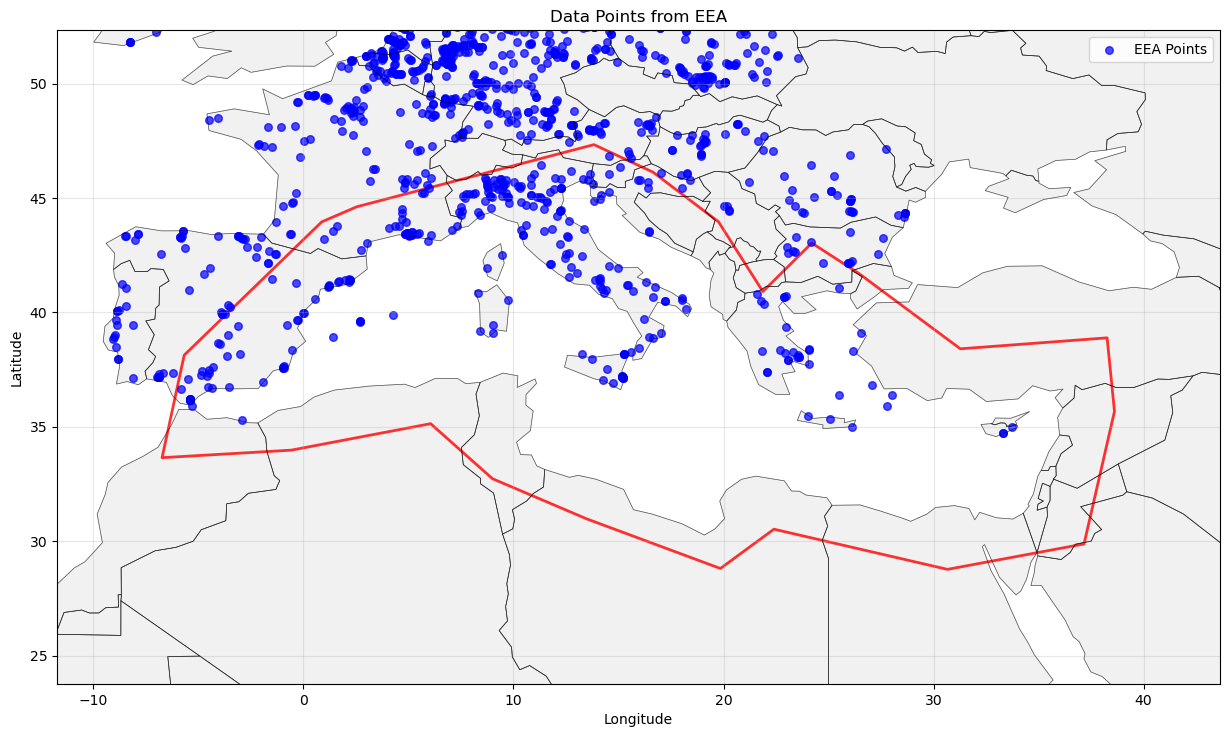

In [17]:
# Import country boundary shapefile from Natural Earth (https://www.naturalearthdata.com/downloads/110m-cultural-vectors/)
world = gpd.read_file('raw/country/ne_110m_admin_0_countries.shp')

# Convert EEA points to GeoDataFrame and set CRS WGS84
geometry = [Point(lon, lat) for lon, lat in zip(df_eea['pointGeometryLon'], df_eea['pointGeometryLat'])]
eea_points = gpd.GeoDataFrame(df_eea, geometry=geometry, crs='EPSG:4326')

# Create the overlay plot
fig, ax = plt.subplots(figsize=(15, 10))

# Plot world countries (background)
world.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3, linewidth=0.5, label='Countries')
world.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.5)

# Plot Area Boundaries
gdf_areas.plot(ax=ax, color='none', edgecolor='red', linewidth=2, alpha=0.8, label='Area Boundaries')

# Plot EEA data points
eea_points.plot(ax=ax, color='blue', markersize=30, alpha=0.7, marker='o', label='EEA Points')

# Customize
ax.set_title('Data Points from EEA')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Auto-scale to area boundary
minx, miny, maxx, maxy = gdf_areas.total_bounds
ax.set_xlim(minx - 5, maxx + 5)
ax.set_ylim(miny - 5, maxy + 5)

plt.show()

---

## Data Set B - Climate TRACE
Data set B are multiple CSV files, downloaded from https://climatetrace.org/data
</br> Using "subsector-name_emissions_sources.csv", Version 5.3.0 January 2026
> cement_emissions_sources_v5_3_0
> </br> iron-and-steel_emissions_sources_v5_3_0
> </br> petrochemical-steam-cracking_emissions_sources_v5_3_0
> </br> oil-and-gas-production_emissions_sources_v5_3_0
> </br> oil-and-gas-refining_emissions_sources_v5_3_0
> </br> electricity-generation_emissions_sources_v5_3_0

### Create Database for Data Set B
Import excel file and store in DuckDB database

In [18]:
# Import all CSV files from raw/climate_trace directory
raw_climate_trace  = glob.glob(os.path.join('raw/climate_trace', '*.csv'))

# Combine all CSV files into a single DataFrame
climate_trace = pd.concat((pd.read_csv(f) for f in raw_climate_trace), ignore_index=True)

# Check imported data
climate_trace

C:\Users\dutka\AppData\Local\Temp\ipykernel_36508\1025120944.py:5: DtypeWarning: Columns (0: other8) have mixed types. Specify dtype option on import or set low_memory=False.
  climate_trace = pd.concat((pd.read_csv(f) for f in raw_climate_trace), ignore_index=True)


,source_id,source_name,source_type,iso3_country,sector,subsector,start_time,end_time,lat,lon,...,other9,other9_def,other10,other10_def,created_date,modified_date,reporting_entity,sector_id,native_source_id,lat_lon
0,42547296,Afghan Cement Ghori I Cement Plant,integrated wet,AFG,manufacturing,cement,2021-01-01 00:00:00,2021-01-31 00:00:00,35.965794,68.687297,...,0.95,clinker_to_cement_ratio,extrapolation (national),model_methodology,2025-07-07 00:00:00,2026-01-09 12:25:17,climate-trace,76.0,TZCMT2505000000157,NaN
1,42547296,Afghan Cement Ghori I Cement Plant,integrated wet,AFG,manufacturing,cement,2021-02-01 00:00:00,2021-02-28 00:00:00,35.965794,68.687297,...,0.95,clinker_to_cement_ratio,extrapolation (national),model_methodology,2025-07-07 00:00:00,2026-01-09 12:25:17,climate-trace,76.0,TZCMT2505000000157,NaN
2,42547296,Afghan Cement Ghori I Cement Plant,integrated wet,AFG,manufacturing,cement,2021-03-01 00:00:00,2021-03-31 00:00:00,35.965794,68.687297,...,0.95,clinker_to_cement_ratio,extrapolation (national),model_methodology,2025-07-07 00:00:00,2026-01-09 12:25:17,climate-trace,76.0,TZCMT2505000000157,NaN
3,42547296,Afghan Cement Ghori I Cement Plant,integrated wet,AFG,manufacturing,cement,2021-04-01 00:00:00,2021-04-30 00:00:00,35.965794,68.687297,...,0.95,clinker_to_cement_ratio,extrapolation (national),model_methodology,2025-07-07 00:00:00,2026-01-09 12:25:17,climate-trace,76.0,TZCMT2505000000157,NaN
4,42547296,Afghan Cement Ghori I Cement Plant,integrated wet,AFG,manufacturing,cement,2021-05-01 00:00:00,2021-05-31 00:00:00,35.965794,68.687297,...,0.95,clinker_to_cement_ratio,extrapolation (national),model_methodology,2025-07-07 00:00:00,2026-01-09 12:25:17,climate-trace,76.0,TZCMT2505000000157,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962344,732018,"Sasol Polymers Secunda, Secunda",Naphtha,ZAF,manufacturing,petrochemical-steam-cracking,2025-07-01 00:00:00,2025-07-31 00:00:00,-26.550959,29.155910,...,NaN,NaN,NaN,NaN,2025-07-03 00:00:00,2026-01-09 23:07:05.734874,climate-trace,NaN,228,NaN
962345,732018,"Sasol Polymers Secunda, Secunda",Naphtha,ZAF,manufacturing,petrochemical-steam-cracking,2025-08-01 00:00:00,2025-08-31 00:00:00,-26.550959,29.155910,...,NaN,NaN,NaN,NaN,2025-07-03 00:00:00,2026-01-09 23:07:05.734874,climate-trace,NaN,228,NaN
962346,732018,"Sasol Polymers Secunda, Secunda",Naphtha,ZAF,manufacturing,petrochemical-steam-cracking,2025-09-01 00:00:00,2025-09-30 00:00:00,-26.550959,29.155910,...,NaN,NaN,NaN,NaN,2025-07-03 00:00:00,2026-01-09 23:07:05.734874,climate-trace,NaN,228,NaN
962347,732018,"Sasol Polymers Secunda, Secunda",Naphtha,ZAF,manufacturing,petrochemical-steam-cracking,2025-10-01 00:00:00,2025-10-31 00:00:00,-26.550959,29.155910,...,NaN,NaN,NaN,NaN,2025-10-06 00:00:00,2026-01-09 23:07:05.734874,climate-trace,NaN,228,NaN


### Querry database
Querry data from database.duckdb, and display selected sector, emissions >= 100 ktCO2, within study area

Selected sectors: Refinery, Steel, Cement, Power Generation, Petrochemicals

In [19]:
# Check 'climate_trace' database structure
con = duckdb.connect('database.duckdb')
print(con.execute("DESCRIBE climate_trace").fetchdf())

               column_name column_type null   key default extra
0                source_id      BIGINT  YES  None    None  None
1              source_name     VARCHAR  YES  None    None  None
2              source_type     VARCHAR  YES  None    None  None
3             iso3_country     VARCHAR  YES  None    None  None
4                   sector     VARCHAR  YES  None    None  None
5                subsector     VARCHAR  YES  None    None  None
6               start_time     VARCHAR  YES  None    None  None
7                 end_time     VARCHAR  YES  None    None  None
8                      lat      DOUBLE  YES  None    None  None
9                      lon      DOUBLE  YES  None    None  None
10            geometry_ref      DOUBLE  YES  None    None  None
11                     gas     VARCHAR  YES  None    None  None
12      emissions_quantity      DOUBLE  YES  None    None  None
13    temporal_granularity     VARCHAR  YES  None    None  None
14                activity      DOUBLE  

In [20]:
# Check subsectors
print(con.execute("SELECT DISTINCT subsector FROM climate_trace ORDER BY subsector").fetchdf())

                      subsector
0                        cement
1        electricity-generation
2                iron-and-steel
3        oil-and-gas-production
4          oil-and-gas-refining
5  petrochemical-steam-cracking


In [21]:
# Query to get most recent year emissions per source with emissions >= 100,000 tCO2  (emission_quantity in tCO2)

query = """
WITH yearly_emissions AS (
    SELECT
        source_id,
        source_name,
        source_type,
        iso3_country,
        sector,
        subsector,
        lat,
        lon,
        CAST(start_time AS TIMESTAMP) AS start_time,
        CAST(end_time AS TIMESTAMP) AS end_time,
        EXTRACT(YEAR FROM CAST(start_time AS DATE)) AS year,
        SUM(emissions_quantity) AS emissions_quantity
    FROM climate_trace
    WHERE EXTRACT(YEAR FROM CAST(start_time AS DATE)) >= 2023
    GROUP BY
        source_id, source_name, source_type, iso3_country,
        sector, subsector, lat, lon,
        start_time, end_time
),
ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY source_id
               ORDER BY year DESC
           ) AS rn
    FROM yearly_emissions
)
SELECT *
FROM ranked
WHERE rn = 1
  AND emissions_quantity >= 100000
ORDER BY emissions_quantity DESC
"""

df_climate_trace = con.execute(query).fetchdf()
con.close()

df_climate_trace

,source_id,source_name,source_type,iso3_country,sector,subsector,lat,lon,start_time,end_time,year,emissions_quantity,rn
0,3588673,Canada_West Canadian - Alberta_Oil sands,NaN,CAN,fossil-fuel-operations,oil-and-gas-production,56.169140,-111.358750,2025-08-01,2025-08-31,2025,1.207384e+07,1
1,42244298,Russia_West Siberia (Central)_Conventional onshore,NaN,RUS,fossil-fuel-operations,oil-and-gas-production,63.149921,75.070287,2025-06-01,2025-06-30,2025,1.203226e+07,1
2,42244330,Saudi Arabia_Widyan - North Arabian Gulf_Conventional onshore,NaN,SAU,fossil-fuel-operations,oil-and-gas-production,25.711951,48.918548,2025-09-01,2025-09-30,2025,7.185757e+06,1
3,42243898,Iran_Zagros Foldbelt_Conventional onshore,NaN,IRN,fossil-fuel-operations,oil-and-gas-production,30.983880,49.394738,2025-03-01,2025-03-31,2025,6.973170e+06,1
4,42243907,Iraq_Widyan - North Arabian Gulf_Conventional onshore,NaN,IRQ,fossil-fuel-operations,oil-and-gas-production,30.876672,47.154895,2025-07-01,2025-07-31,2025,5.491538e+06,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3808,1895647,Lincheng Zhonglian Fushi Cement Co Ltd Cement Plant,integrated dry,CHN,manufacturing,cement,37.524691,114.442408,2025-06-01,2025-06-30,2025,1.001153e+05,1
3809,25449374,Wise County Power LLC,gas,USA,power,electricity-generation,33.059900,-97.909500,2025-05-01,2025-05-31,2025,1.001000e+05,1
3810,25452124,Jijel power station,gas,DZA,power,electricity-generation,36.813900,5.876000,2025-04-01,2025-04-30,2025,1.001000e+05,1
3811,32438273,Laiwu Lubi Cement Manufacturing Co. Cement Plant,integrated dry,CHN,manufacturing,cement,36.106681,117.834362,2025-05-01,2025-05-31,2025,1.000898e+05,1


In [22]:
# Add 'emission_tco2' column
df_climate_trace['emissions_tco2'] = df_climate_trace['emissions_quantity']

C:\Users\dutka\AppData\Local\Temp\ipykernel_36508\1128018774.py:25: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


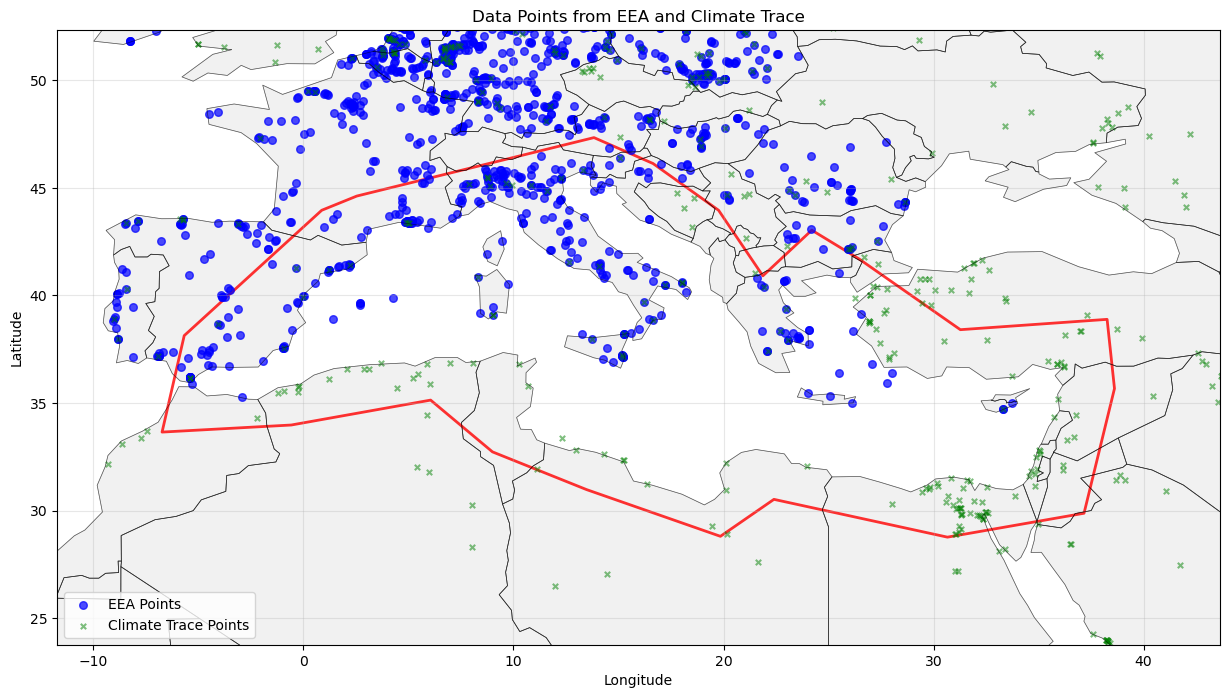

In [23]:
# Convert df_climate_trace points to GeoDataFrame and set CRS WGS84
climate_trace_geometry = [Point(lon, lat) for lon, lat in zip(df_climate_trace['lon'], df_climate_trace['lat'])]
climate_trace_points = gpd.GeoDataFrame(df_climate_trace, geometry=climate_trace_geometry, crs='EPSG:4326')

# Create the overlay plot
fig, ax = plt.subplots(figsize=(15, 10))

# Plot world countries (background)
world.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3, linewidth=0.5, label='Countries')
world.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.5)

# Plot Area Boundaries
gdf_areas.plot(ax=ax, color='none', edgecolor='red', linewidth=2, alpha=0.8, label='Area Boundaries')

# Plot EEA data points
eea_points.plot(ax=ax, color='blue', markersize=30, alpha=0.7, marker='o', label='EEA Points')

# Plot Climate Trace data points
climate_trace_points.plot(ax=ax, color='green', markersize=15, alpha=0.5, marker='x', label='Climate Trace Points')

# Customize
ax.set_title('Data Points from EEA and Climate Trace')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Auto-scale to area boundary
minx, miny, maxx, maxy = gdf_areas.total_bounds
ax.set_xlim(minx - 5, maxx + 5)
ax.set_ylim(miny - 5, maxy + 5)

plt.show()

---

## Data Set C - Carbon Mapper (Not Use)
API request to get (source) data from Carbon Mapper: https://api.carbonmapper.org/api/v1/docs
</br>
</br> Need to be register for getting token. Then, saved token as text file 
</br>
</br> "emission_auto" is reported in kg/hour. Quantified emissionrate calculate dusing the mean of all emissions attributed to a source weighted by persistence (Frequency of detection OR number of plume detection days divided by the number of observation days)

#### API Request by source

#### Alternative ( Not use)
API request Plume

#### Plot in the map

---

## Data Validation

Check the overlapping data between EEA & Climate TRACE

### Clipping data within focusing area

### Merge two datasets by spatial proximity (relaxed lat/lon criteria)

### Export 

---

## Export Clipped EEA & Climate TRACE Dataframe for dashabord

___

# CO2 Storage

The raw excel file of CO2 storage data was prepared manually as many data sources were from Annoucement, Articles and Report. Only CO2StoP was extracted from MS Access database ('CO2Stop_DataInterrogationSystem')

In [94]:
# Import excel file

df_storage = pd.read_excel('raw/storage.xlsx')


In [95]:
# convert x,y to lat, lon for storage dataframe
# if lat, lon data is missing, use x, y columns and EPSG column to convert to lat, lon


def convert_to_lat_lon(row):
    # Keep existing lat/lon if available
    if pd.notna(row['lat']) and pd.notna(row['lon']):
        return pd.Series({'lat': row['lat'], 'lon': row['lon']})
    
    # Convert from x,y using EPSG if available
    if pd.notna(row.get('EPSG')) and pd.notna(row.get('x')) and pd.notna(row.get('y')):
        try:
            proj = Proj(f"epsg:{row['EPSG']}")
            lon, lat = proj(row['x'], row['y'], inverse=True)
            return pd.Series({'lat': lat, 'lon': lon})
        except:
            pass
    
    # Return NaN if data is missing or conversion fails
    return pd.Series({'lat': pd.NA, 'lon': pd.NA})

df_storage[['lat', 'lon']] = df_storage.apply(convert_to_lat_lon, axis=1)

In [96]:
# Drop data where lat or lon is missing after conversion
df_storage = df_storage.dropna(subset=['lat', 'lon'])  

# Drop storage where 'TOTAL_CAPACITY_BASE_MT' <15 MT & > 5,000 MT
df_storage = df_storage[(df_storage['TOTAL_CAPACITY_BASE_MT'] >= 15) & (df_storage['TOTAL_CAPACITY_BASE_MT'] <= 5000)]


# Drop storage where 'REMAINING RATIO' >= 0.4, keeping N/A
df_storage = df_storage[(df_storage['REMAINING_RATIO'] < 0.4) | (df_storage['REMAINING_RATIO'].isna())]

In [97]:
df_storage['CONFIDENCE_TIER'].value_counts(dropna=False)

CONFIDENCE_TIER
5    105
4     18
1      3
3      1
Name: count, dtype: int64

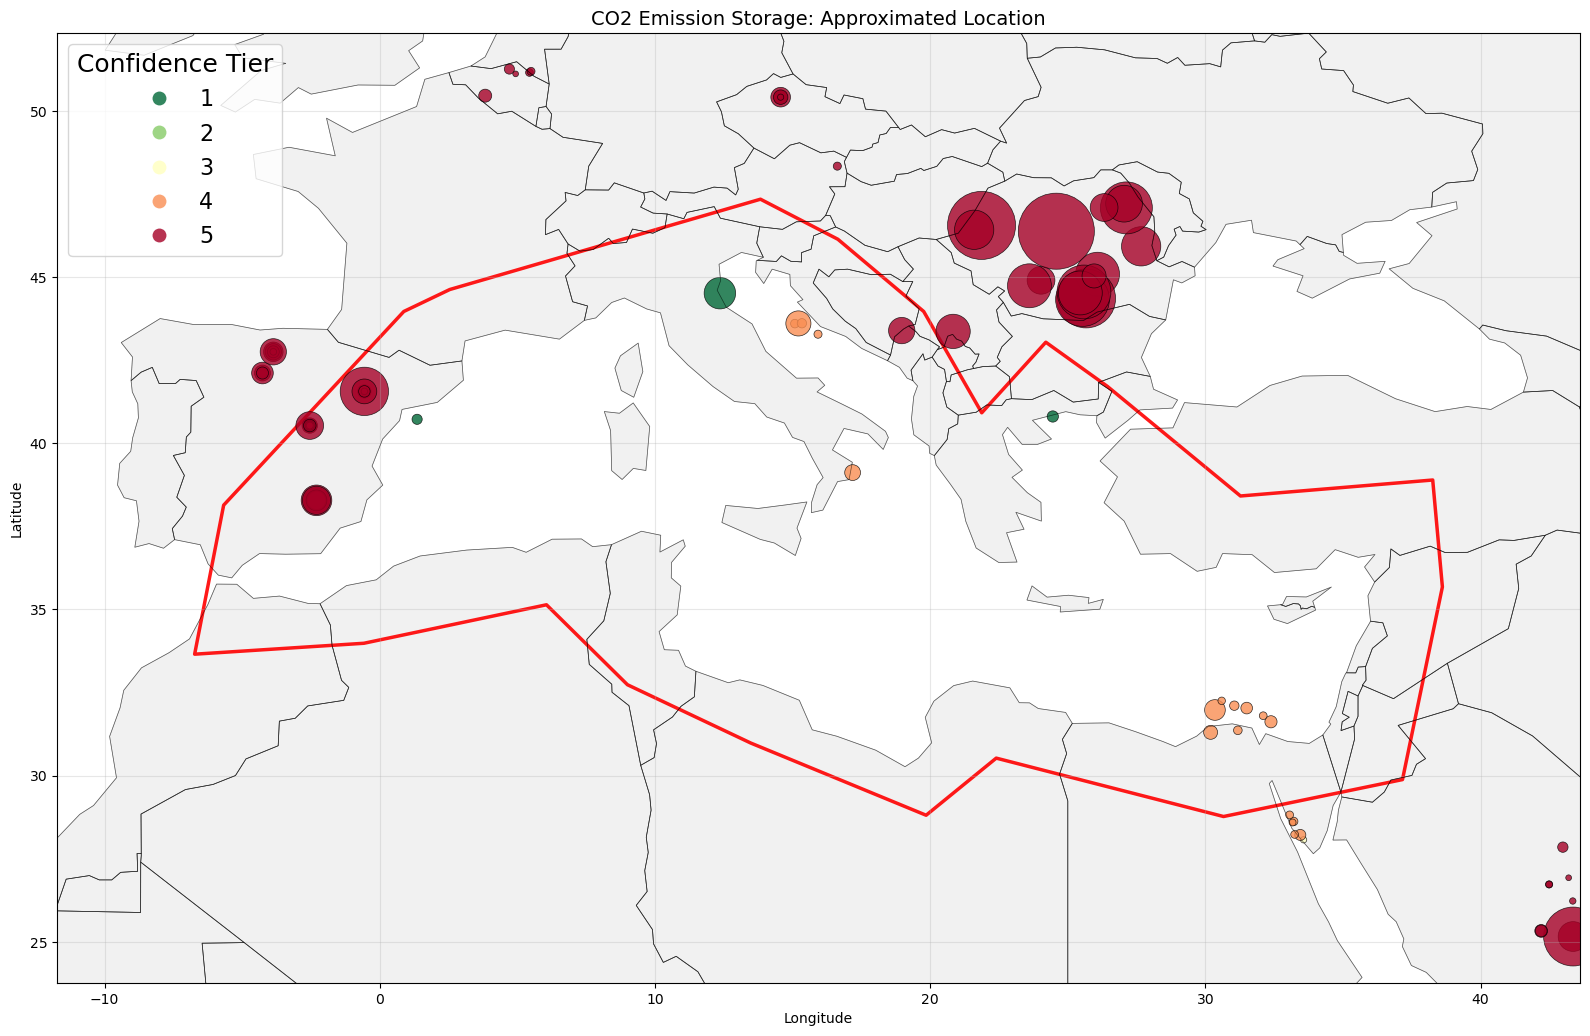

In [98]:
# Plot storage sites on map, color by 'CONFIDENCE_TIER'
storage_geometry = [Point(lon, lat) for lon, lat in zip(df_storage['lon'], df_storage['lat'])]
storage_points = gpd.GeoDataFrame(df_storage, geometry=storage_geometry, crs='EPSG:4326')  

# Ensure 'CONFIDENCE_TIER' is treated as a categorical variable for plotting
storage_points['CONFIDENCE_TIER'] = pd.Categorical(storage_points['CONFIDENCE_TIER'], categories=[1, 2, 3, 4, 5], ordered=True)


# Create overlay map with all three datasets
fig, ax = plt.subplots(figsize=(16, 12))

# Plot world countries (background)
world.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3, linewidth=0.5, label='Countries')
world.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.5)

# Plot Area Boundaries
gdf_areas.plot(ax=ax, color='none', edgecolor='red', linewidth=2.5, alpha=0.9, label='Study Area')


# Plot storage data points, color by 'CONFIDENCE_TIER', size by 'TOTAL_CAPACITY_BASE_MT'
storage_points.plot(
    ax=ax,
    column='CONFIDENCE_TIER',
    cmap=plt.get_cmap('RdYlGn_r', 5),
    categorical=True,
    markersize=storage_points['TOTAL_CAPACITY_BASE_MT'],
    alpha=0.8,
    marker='o',
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'title': 'Confidence Tier', 'loc': 'upper left', 'fontsize': 16, 'title_fontsize': 18}
)

# Customize
ax.set_title('CO2 Emission Storage: Approximated Location', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

# Auto-scale to area boundary
minx, miny, maxx, maxy = gdf_areas.total_bounds
ax.set_xlim(minx - 5, maxx + 5)
ax.set_ylim(miny - 5, maxy + 5)

plt.tight_layout()
plt.show()



In [99]:


# Export dataframe
df_storage.to_csv("export/df_storage.csv", index=False)

___

## Oil & Gas Infrastructure
Ref.
</br> O'Brien, M., Omara, M., Himmelberger, A., & Gautam, R. (2025). Oil and Gas Infrastructure Mapping (OGIM) database (OGIM_v2.7) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.15103476

In [100]:
import fiona

# Load OGIM data
ogim_path = "raw/OGIM_v2.7.gpkg"

# Read the GeoPackage layers
# First, let's see what layers are available
layers = fiona.listlayers(ogim_path)
print(f"Available layers in OGIM: {layers}")

Available layers in OGIM: ['Crude_Oil_Refineries', 'Equipment_and_Components', 'Gathering_and_Processing', 'Injection_and_Disposal', 'LNG_Facilities', 'Natural_Gas_Compressor_Stations', 'Natural_Gas_Flaring_Detections', 'Offshore_Platforms', 'Oil_Natural_Gas_Pipelines', 'Oil_and_Natural_Gas_Basins', 'Oil_and_Natural_Gas_Fields', 'Oil_and_Natural_Gas_License_Blocks', 'Oil_and_Natural_Gas_Wells', 'Petroleum_Terminals', 'Stations_Other', 'Tank_Battery', 'Data_Catalog']


### Clipping Oil & Gas Infrastructure since the data is too large

In [101]:
# Import Area Boundary and NUTS GEOJSON file
gdf_areas_extended = gpd.read_file('raw/Area_Boundary_Extended.geojson')

C:\Users\dutka\AppData\Local\Temp\ipykernel_36508\1872547960.py:60: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=10, loc="upper left")


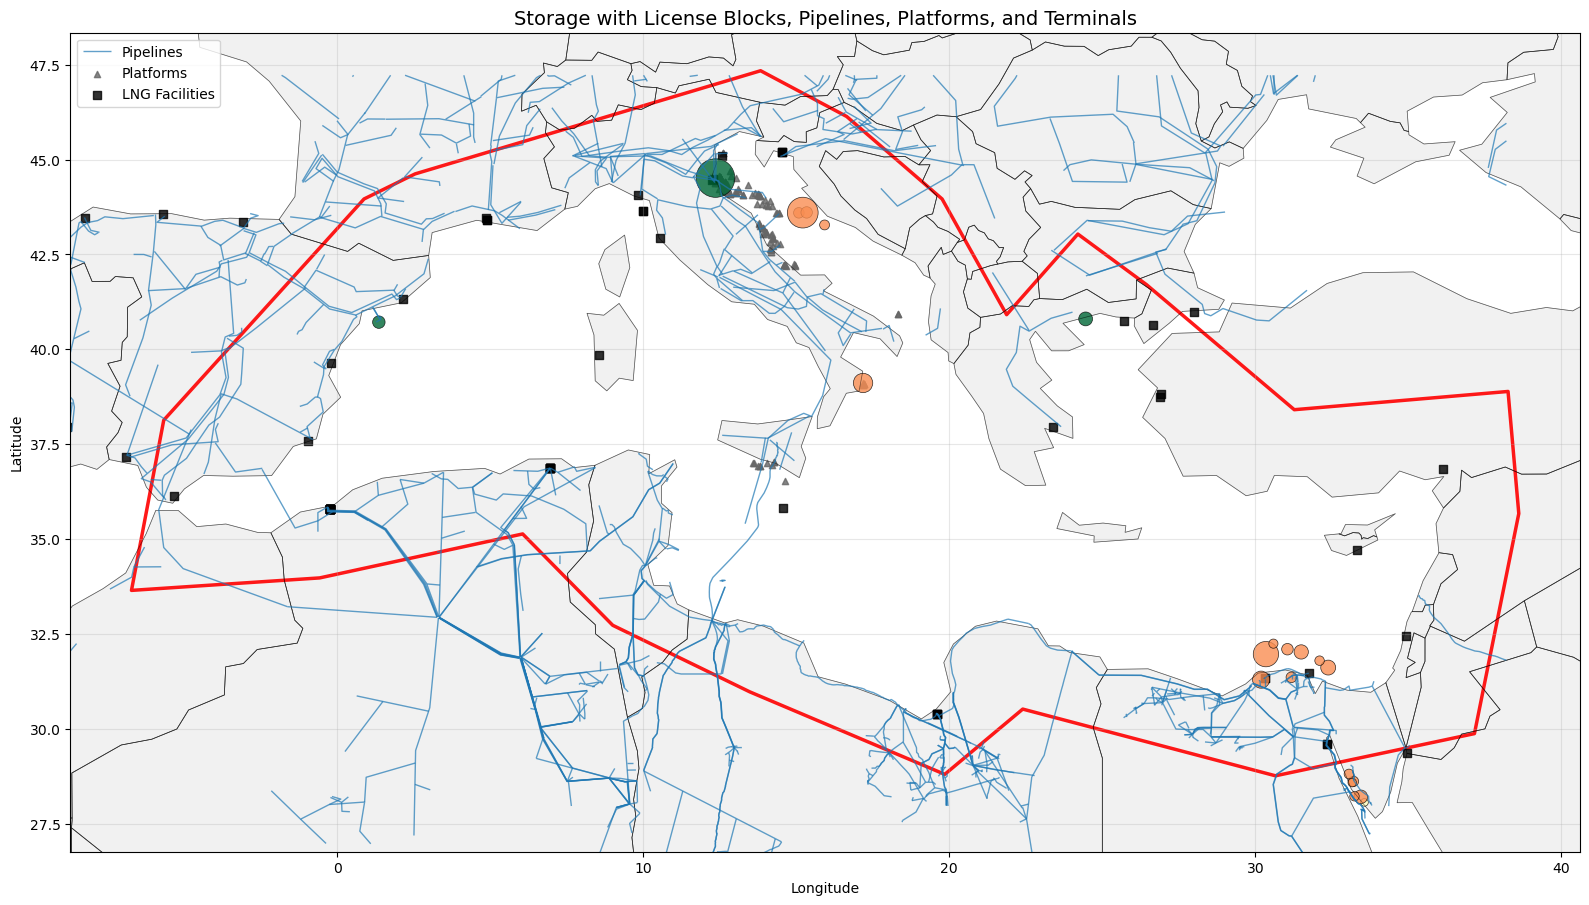

In [102]:
# Load OGIM layers
gdf_pipelines = gpd.read_file(ogim_path, layer="Oil_Natural_Gas_Pipelines")
gdf_platforms = gpd.read_file(ogim_path, layer="Offshore_Platforms")
gdf_terminals = gpd.read_file(ogim_path, layer="LNG_Facilities")

# Align CRS before clipping
target_crs = gdf_areas_extended.crs
if gdf_pipelines.crs != target_crs:
    gdf_pipelines = gdf_pipelines.to_crs(target_crs)
if gdf_platforms.crs != target_crs:
    gdf_platforms = gdf_platforms.to_crs(target_crs)
if gdf_terminals.crs != target_crs:
    gdf_terminals = gdf_terminals.to_crs(target_crs)

# Clip to extended area boundary
gdf_pipelines = gpd.clip(gdf_pipelines, gdf_areas_extended)
gdf_platforms = gpd.clip(gdf_platforms, gdf_areas_extended)
gdf_terminals = gpd.clip(gdf_terminals, gdf_areas_extended)

# Drop empty/invalid geometries to avoid plotting errors
gdf_pipelines = gdf_pipelines[gdf_pipelines.geometry.notna() & ~gdf_pipelines.geometry.is_empty]
gdf_platforms = gdf_platforms[gdf_platforms.geometry.notna() & ~gdf_platforms.geometry.is_empty]
gdf_terminals = gdf_terminals[gdf_terminals.geometry.notna() & ~gdf_terminals.geometry.is_empty]

# Reuse storage_points from the previous cell
fig, ax = plt.subplots(figsize=(16, 12))

world.plot(ax=ax, color="lightgray", edgecolor="black", alpha=0.3, linewidth=0.5)
world.boundary.plot(ax=ax, color="black", linewidth=0.5, alpha=0.5)
gdf_areas.plot(ax=ax, color="none", edgecolor="red", linewidth=2.5, alpha=0.9, label="Study Area")

gdf_pipelines.plot(ax=ax, color="#1f78b4", linewidth=1.0, alpha=0.7, label="Pipelines")
gdf_platforms.plot(ax=ax, color="#666666", markersize=20, alpha=0.8, marker="^", label="Platforms")
gdf_terminals.plot(ax=ax, color="#000000", markersize=35, alpha=0.8, marker="s", label="LNG Facilities")


# Drop storage points where confidence tier == 5 (lowest confidence) to avoid cluttering the map
storage_points = storage_points[storage_points['CONFIDENCE_TIER'] != 5]



# Plot storage data points, color by 'CONFIDENCE_TIER', size by 'TOTAL_CAPACITY_BASE_MT'
storage_points.plot(
    ax=ax,
    column='CONFIDENCE_TIER',
    cmap=plt.get_cmap('RdYlGn_r', 5),
    categorical=True,
    markersize=storage_points['TOTAL_CAPACITY_BASE_MT']*1.5,
    alpha=0.8,
    marker='o',
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'title': 'Confidence Tier', 'loc': 'upper left', 'fontsize': 16, 'title_fontsize': 18}
)

ax.set_title("Storage with License Blocks, Pipelines, Platforms, and Terminals", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)

minx, miny, maxx, maxy = gdf_areas.total_bounds
ax.set_xlim(minx - 2, maxx + 2)
ax.set_ylim(miny - 2, maxy + 1)

plt.tight_layout()
plt.show()